In [1]:
import os

# Create project structure
os.makedirs('/content/Data-Analytics-PBL-VLSI/data', exist_ok=True)
os.makedirs('/content/Data-Analytics-PBL-VLSI/notebooks', exist_ok=True)
os.makedirs('/content/Data-Analytics-PBL-VLSI/plots', exist_ok=True)
os.makedirs('/content/Data-Analytics-PBL-VLSI/report', exist_ok=True)

print("Project folders created successfully")

Project folders created successfully


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style="whitegrid")
print("All libraries loaded successfully")

All libraries loaded successfully


In [4]:
# Load original wide format
df = pd.read_csv('/content/Data-Analytics-PBL-VLSI/data/vlsi_metrics.csv')

print("Shape:", df.shape)
print("\nColumns:", list(df.columns))
print("\nFlow Status:", df['flow_status'].values[0])
print("Design:", df['design_name'].values[0])

Shape: (1, 94)

Columns: ['design', 'design_name', 'config', 'flow_status', 'total_runtime', 'routed_runtime', '(Cell/mm^2)/Core_Util', 'DIEAREA_mm^2', 'CellPer_mm^2', 'OpenDP_Util', 'Final_Util', 'Peak_Memory_Usage_MB', 'synth_cell_count', 'tritonRoute_violations', 'Short_violations', 'MetSpc_violations', 'OffGrid_violations', 'MinHole_violations', 'Other_violations', 'Magic_violations', 'pin_antenna_violations', 'net_antenna_violations', 'lvs_total_errors', 'cvc_total_errors', 'klayout_violations', 'wire_length', 'vias', 'wns', 'pl_wns', 'optimized_wns', 'fastroute_wns', 'spef_wns', 'tns', 'pl_tns', 'optimized_tns', 'fastroute_tns', 'spef_tns', 'HPWL', 'routing_layer1_pct', 'routing_layer2_pct', 'routing_layer3_pct', 'routing_layer4_pct', 'routing_layer5_pct', 'routing_layer6_pct', 'wires_count', 'wire_bits', 'public_wires_count', 'public_wire_bits', 'memories_count', 'memory_bits', 'processes_count', 'cells_pre_abc', 'AND', 'DFF', 'NAND', 'NOR', 'OR', 'XOR', 'XNOR', 'MUX', 'inputs',

In [5]:
# Extract key metrics from actual dataset

row = df.iloc[0]

df_long = pd.DataFrame({
    'Metric': [
        'Cell Count (Synthesis)',
        'Total Cells (with Physical)',
        'Core Area (um²)',
        'Die Area (mm²)',
        'Wire Length (um)',
        'Vias Count',
        'WNS (ns)',
        'TNS (ns)',
        'Critical Path (ns)',
        'Suggested Clock Period (ns)',
        'Power Internal (uW)',
        'Power Switching (uW)',
        'Power Leakage (uW)',
    ],
    'Value': [
        row['synth_cell_count'],
        row['TotalCells'],
        row['CoreArea_um^2'],
        row['DIEAREA_mm^2'],
        row['wire_length'],
        row['vias'],
        row['wns'],
        row['tns'],
        row['critical_path_ns'],
        row['suggested_clock_period'],
        row['power_typical_internal_uW'],
        row['power_typical_switching_uW'],
        row['power_typical_leakage_uW'],
    ],
    'Category': [
        'Synthesis','Physical','Physical','Physical',
        'Routing','Routing',
        'Timing','Timing','Timing','Timing',
        'Power','Power','Power'
    ]
})

df_long.to_csv('/content/Data-Analytics-PBL-VLSI/data/vlsi_long_format.csv', index=False)
print(df_long)

                         Metric         Value   Category
0        Cell Count (Synthesis)  1.150000e+02  Synthesis
1   Total Cells (with Physical)  3.450000e+02   Physical
2               Core Area (um²)  1.941862e+03   Physical
3                Die Area (mm²)  3.702648e-03   Physical
4              Wire Length (um)  2.748000e+03    Routing
5                    Vias Count  9.690000e+02    Routing
6                      WNS (ns)  0.000000e+00     Timing
7                      TNS (ns)  0.000000e+00     Timing
8            Critical Path (ns)  2.340000e+00     Timing
9   Suggested Clock Period (ns)  1.000000e+01     Timing
10          Power Internal (uW)  2.550000e-05      Power
11         Power Switching (uW)  3.530000e-05      Power
12           Power Leakage (uW)  7.470000e-10      Power


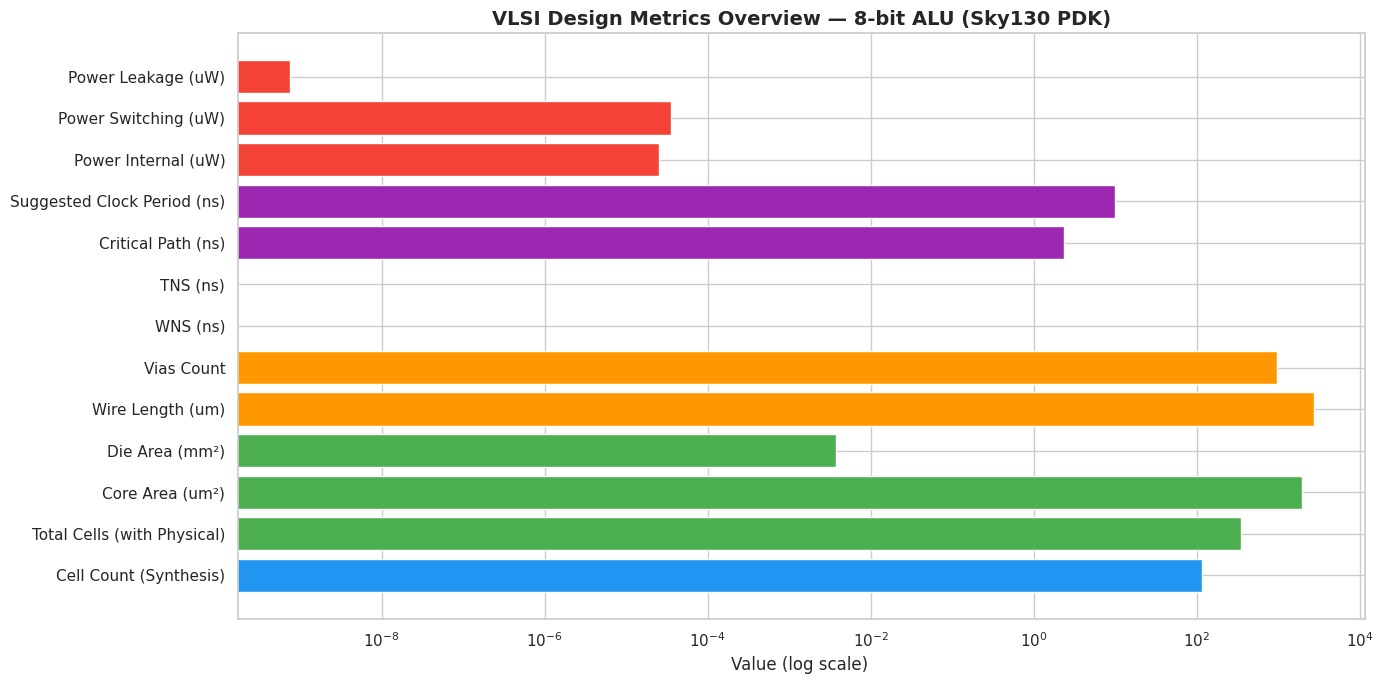

Plot saved


In [12]:
fig, ax = plt.subplots(figsize=(14, 7))
colors = df_long['Category'].map({
    'Synthesis': '#2196F3',
    'Physical': '#4CAF50',
    'Routing': '#FF9800',
    'Timing': '#9C27B0',
    'Power': '#F44336',
    'Cell Types': '#00BCD4',
    'Physical Cells': '#795548'
})

bars = ax.barh(df_long['Metric'], df_long['Value'], color=colors)
ax.set_xscale('log')
ax.set_xlabel('Value (log scale) ', fontsize=12)
ax.set_title('VLSI Design Metrics Overview — 8-bit ALU (Sky130 PDK)', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('/content/Data-Analytics-PBL-VLSI/plots/01_metrics_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved")

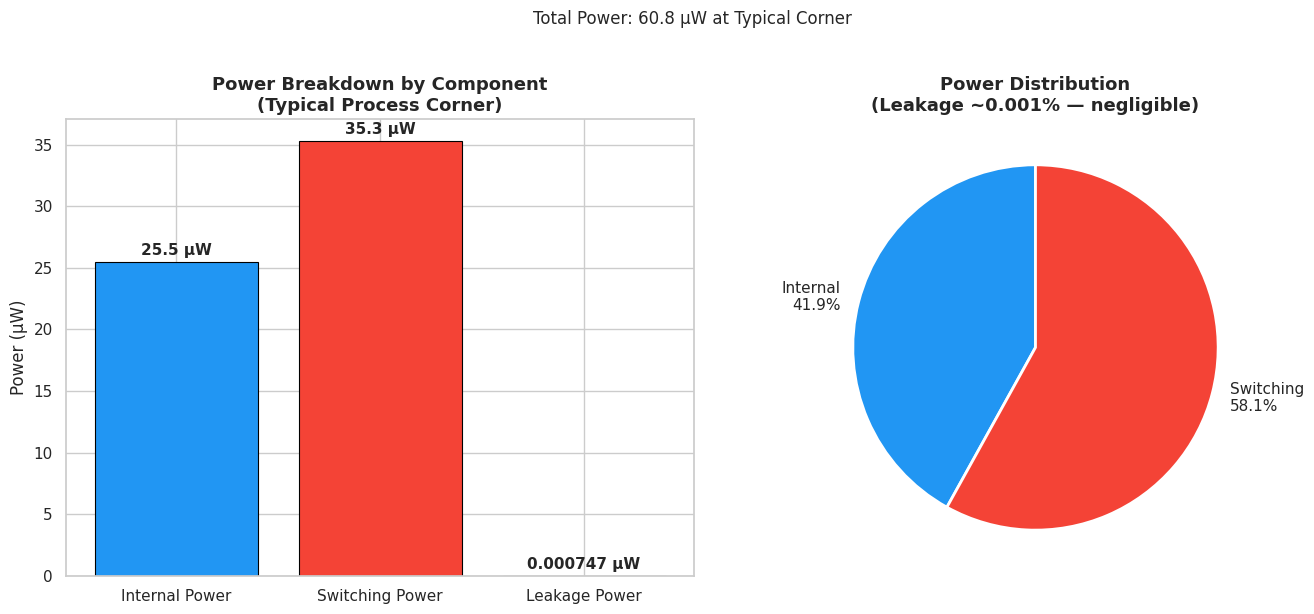

In [15]:
# Cell 5 — EDA: Power Breakdown

power_data = {
    'Component': ['Internal Power', 'Switching Power', 'Leakage Power'],
    'Value_uW': [25.5, 35.3, 0.000747],
    'Percentage': [41.9, 58.1, 0.001]
}

power_df = pd.DataFrame(power_data)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot
bars = ax1.bar(power_df['Component'], power_df['Value_uW'],
               color=['#2196F3', '#F44336', '#4CAF50'],
               edgecolor='black', linewidth=0.8)

ax1.set_ylabel('Power (µW)', fontsize=12)
ax1.set_title('Power Breakdown by Component\n(Typical Process Corner)', fontsize=13, fontweight='bold')

for bar, val in zip(bars, power_df['Value_uW']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val} µW', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart (excluding leakage)
ax2.pie([25.5, 35.3],
        labels=['Internal\n41.9%', 'Switching\n58.1%'],
        colors=['#2196F3', '#F44336'],
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

ax2.set_title('Power Distribution\n(Leakage ~0.001% — negligible)', fontsize=13, fontweight='bold')

plt.suptitle('Total Power: 60.8 µW at Typical Corner', fontsize=12, y=1.02)

plt.tight_layout()

plt.savefig('/content/Data-Analytics-PBL-VLSI/plots/02_power_breakdown.png',
            dpi=150, bbox_inches='tight')

plt.show()

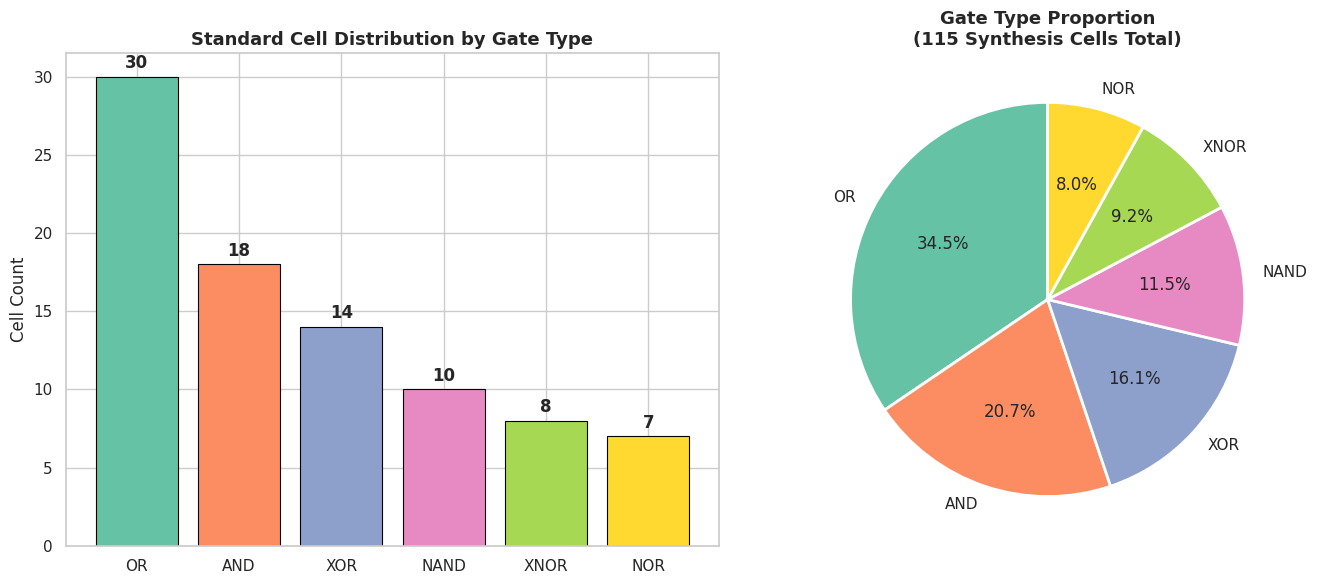

Plot saved successfully ✅


In [18]:
# Cell 6 — EDA: Cell Type Distribution

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Data
cell_data = {
    'Gate Type': ['OR', 'AND', 'NAND', 'XOR', 'XNOR', 'NOR'],
    'Count': [30, 18, 10, 14, 8, 7]
}

# Create DataFrame and sort
cell_df = pd.DataFrame(cell_data).sort_values('Count', ascending=False)

# Plot setup
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Color palette
palette = sns.color_palette("Set2", len(cell_df))

# Bar plot
bars = ax1.bar(cell_df['Gate Type'], cell_df['Count'],
               color=palette, edgecolor='black', linewidth=0.8)

ax1.set_ylabel('Cell Count', fontsize=12)
ax1.set_title('Standard Cell Distribution by Gate Type', fontsize=13, fontweight='bold')

# Add value labels
for bar, val in zip(bars, cell_df['Count']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

# Pie chart
ax2.pie(cell_df['Count'],
        labels=cell_df['Gate Type'],
        colors=palette,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

ax2.set_title('Gate Type Proportion\n(115 Synthesis Cells Total)',
              fontsize=13, fontweight='bold')

# Save + show
plt.tight_layout()
plt.savefig('/content/Data-Analytics-PBL-VLSI/plots/03_cell_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved successfully ✅")

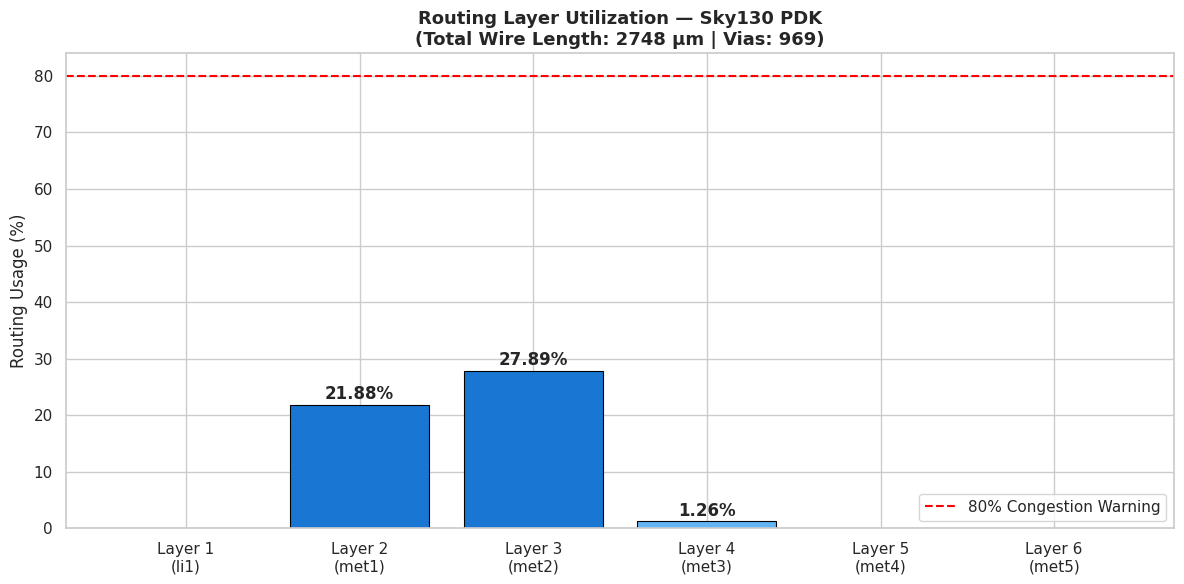

Insight: Design uses primarily met1 and met2. No congestion detected (all layers well below 80%).


In [19]:
# Cell 7 — EDA: Routing Layer Usage

import pandas as pd
import matplotlib.pyplot as plt

# Data
routing_data = {
    'Layer': [
        'Layer 1\n(li1)',
        'Layer 2\n(met1)',
        'Layer 3\n(met2)',
        'Layer 4\n(met3)',
        'Layer 5\n(met4)',
        'Layer 6\n(met5)'
    ],
    'Usage_pct': [0.0, 21.88, 27.89, 1.26, 0.0, 0.0]
}

routing_df = pd.DataFrame(routing_data)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

colors = [
    '#E0E0E0' if v == 0 else '#1976D2' if v > 20 else '#64B5F6'
    for v in routing_df['Usage_pct']
]

bars = ax.bar(routing_df['Layer'],
              routing_df['Usage_pct'],
              color=colors,
              edgecolor='black',
              linewidth=0.8)

# Labels and title
ax.set_ylabel('Routing Usage (%)', fontsize=12)
ax.set_title(
    'Routing Layer Utilization — Sky130 PDK\n'
    '(Total Wire Length: 2748 µm | Vias: 969)',
    fontsize=13,
    fontweight='bold'
)

# Congestion line
ax.axhline(y=80,
           color='red',
           linestyle='--',
           linewidth=1.5,
           label='80% Congestion Warning')

ax.legend(fontsize=11)

# Value labels
for bar, val in zip(bars, routing_df['Usage_pct']):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.3,
                f'{val}%',
                ha='center',
                va='bottom',
                fontsize=12,
                fontweight='bold')

# Save + show
plt.tight_layout()
plt.savefig('/content/Data-Analytics-PBL-VLSI/plots/04_routing_layers.png',
            dpi=150,
            bbox_inches='tight')
plt.show()

print("Insight: Design uses primarily met1 and met2. No congestion detected (all layers well below 80%).")

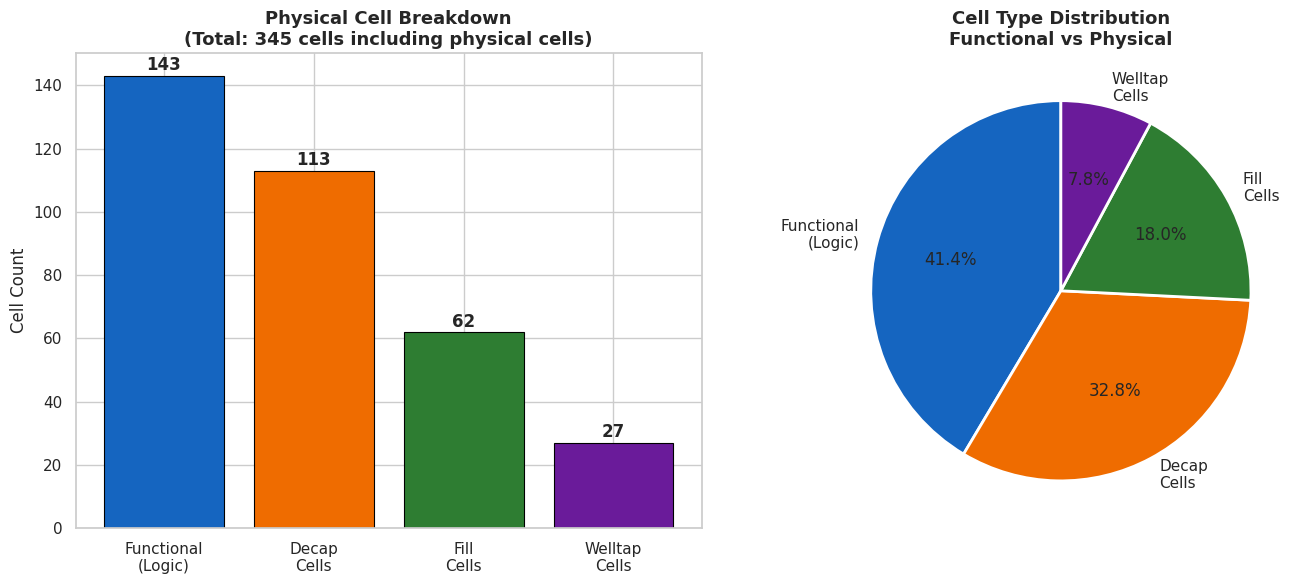

Physical cell breakdown plot saved ✅


In [20]:
# Cell 8 — EDA: Physical Cell Breakdown

import pandas as pd
import matplotlib.pyplot as plt

# Data
physical_cells = {
    'Cell Type': [
        'Functional\n(Logic)',
        'Decap\nCells',
        'Fill\nCells',
        'Welltap\nCells'
    ],
    'Count': [143, 113, 62, 27],
    'Purpose': [
        'Logic Operation',
        'Power Decoupling',
        'Area Fill',
        'Latch-up Prevention'
    ]
}

phys_df = pd.DataFrame(physical_cells)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

colors = ['#1565C0', '#EF6C00', '#2E7D32', '#6A1B9A']

# Bar plot
bars = ax1.bar(phys_df['Cell Type'],
               phys_df['Count'],
               color=colors,
               edgecolor='black',
               linewidth=0.8)

ax1.set_ylabel('Cell Count', fontsize=12)
ax1.set_title('Physical Cell Breakdown\n(Total: 345 cells including physical cells)',
              fontsize=13,
              fontweight='bold')

# Value labels
for bar, val in zip(bars, phys_df['Count']):
    ax1.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.5,
             str(val),
             ha='center',
             va='bottom',
             fontsize=12,
             fontweight='bold')

# Pie chart
ax2.pie(phys_df['Count'],
        labels=phys_df['Cell Type'],
        colors=colors,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 2})

ax2.set_title('Cell Type Distribution\nFunctional vs Physical',
              fontsize=13,
              fontweight='bold')

# Save + show
plt.tight_layout()
plt.savefig('/content/Data-Analytics-PBL-VLSI/plots/05_physical_cells.png',
            dpi=150,
            bbox_inches='tight')
plt.show()

print("Physical cell breakdown plot saved ✅")

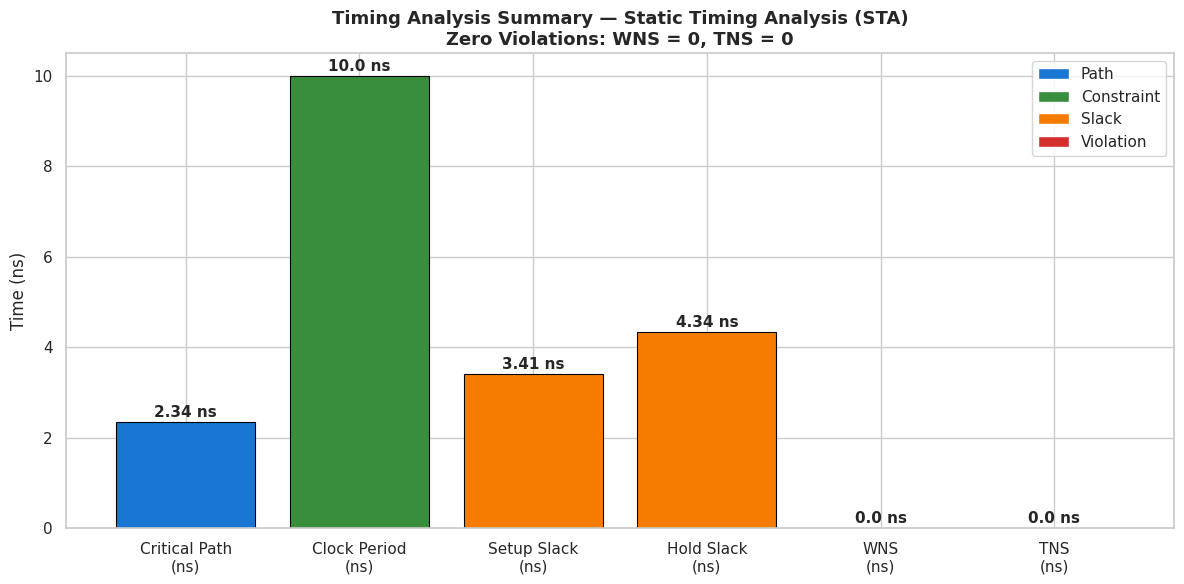

Insight: Critical path is 2.34ns vs 10ns clock → ~34% timing margin ✅


In [21]:
# Cell 9 — EDA: Timing Summary Visual

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Data
timing_metrics = {
    'Metric': [
        'Critical Path\n(ns)',
        'Clock Period\n(ns)',
        'Setup Slack\n(ns)',
        'Hold Slack\n(ns)',
        'WNS\n(ns)',
        'TNS\n(ns)'
    ],
    'Value': [2.34, 10.0, 3.41, 4.34, 0.0, 0.0],
    'Type': ['Path', 'Constraint', 'Slack', 'Slack', 'Violation', 'Violation']
}

timing_df = pd.DataFrame(timing_metrics)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

colors_t = {
    'Path': '#1976D2',
    'Constraint': '#388E3C',
    'Slack': '#F57C00',
    'Violation': '#D32F2F'
}

bar_colors = [colors_t[t] for t in timing_df['Type']]

bars = ax.bar(timing_df['Metric'],
              timing_df['Value'],
              color=bar_colors,
              edgecolor='black',
              linewidth=0.8)

# Labels & title
ax.set_ylabel('Time (ns)', fontsize=12)
ax.set_title(
    'Timing Analysis Summary — Static Timing Analysis (STA)\n'
    'Zero Violations: WNS = 0, TNS = 0',
    fontsize=13,
    fontweight='bold'
)

# Value labels
for bar, val in zip(bars, timing_df['Value']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{val} ns',
            ha='center',
            va='bottom',
            fontsize=11,
            fontweight='bold')

# Legend
legend_elements = [Patch(facecolor=v, label=k) for k, v in colors_t.items()]
ax.legend(handles=legend_elements, fontsize=11)

# Save + show
plt.tight_layout()
plt.savefig('/content/Data-Analytics-PBL-VLSI/plots/06_timing_summary.png',
            dpi=150,
            bbox_inches='tight')
plt.show()

print("Insight: Critical path is 2.34ns vs 10ns clock → ~34% timing margin ✅")

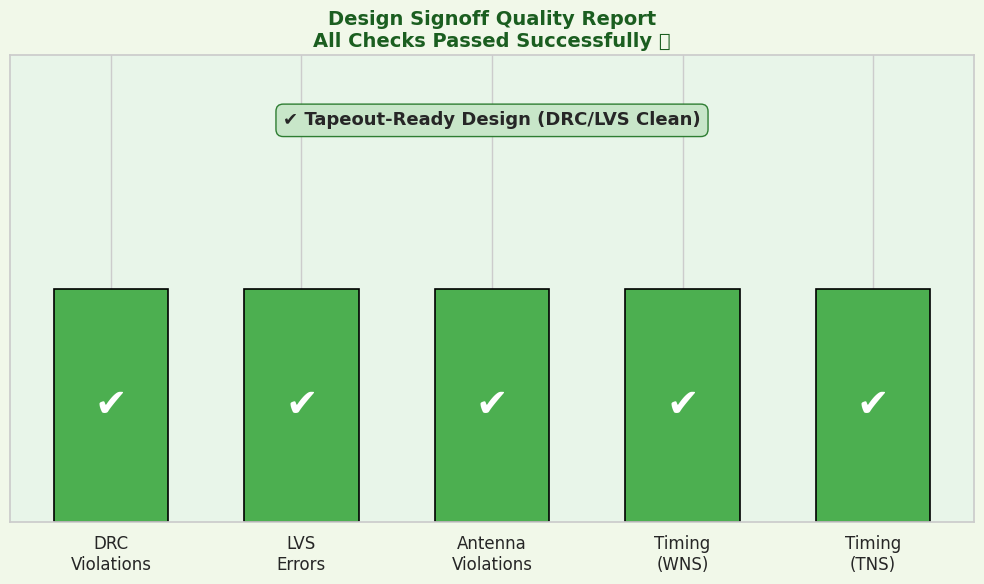

In [23]:
# Cell 10 — EDA: Design Quality Scorecard (Improved)

import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

categories = [
    'DRC\nViolations',
    'LVS\nErrors',
    'Antenna\nViolations',
    'Timing\n(WNS)',
    'Timing\n(TNS)'
]

values = [0, 0, 0, 0, 0]

x = np.arange(len(categories))

# Draw bars (small visible height so they appear)
bars = ax.bar(x,
              [0.5]*len(values),
              color='#4CAF50',
              edgecolor='black',
              linewidth=1.2,
              width=0.6)

# Add big checkmarks
for i in range(len(categories)):
    ax.text(x[i],
            0.25,
            '✔',
            ha='center',
            va='center',
            fontsize=28,
            color='white',
            fontweight='bold')

# Labels
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)

# Remove y-axis
ax.set_yticks([])
ax.set_ylim(0, 1)

# Title
ax.set_title(
    'Design Signoff Quality Report\nAll Checks Passed Successfully ✅',
    fontsize=14,
    fontweight='bold',
    color='#1B5E20'
)

# Background styling
ax.set_facecolor('#E8F5E9')
fig.patch.set_facecolor('#F1F8E9')

# Highlight message
ax.text(0.5,
        0.85,
        '✔ Tapeout-Ready Design (DRC/LVS Clean)',
        transform=ax.transAxes,
        ha='center',
        fontsize=13,
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4',
                  facecolor='#C8E6C9',
                  edgecolor='#2E7D32'))

# Save
plt.tight_layout()
plt.savefig('/content/Data-Analytics-PBL-VLSI/plots/07_signoff_scorecard.png',
            dpi=150,
            bbox_inches='tight')

plt.show()

In [24]:
# Cell 11 — ML Demo: Power Prediction

import numpy as np
import pandas as pd

print("=" * 60)
print("PREDICTIVE MODELLING — METHODOLOGY DEMONSTRATION")
print("=" * 60)

print("""
Note:
This project has only one real design sample.
So ML model is demonstrated using simulated data
based on realistic VLSI scaling trends.
""")

# Simulated dataset
np.random.seed(42)

cell_counts = np.array([50, 75, 100, 115, 130, 160, 200, 250, 300, 400])
base_power = 0.48  # uW per cell (approx realistic scaling)

noise = np.random.normal(0, 2, len(cell_counts))
total_power = cell_counts * base_power + noise

sim_df = pd.DataFrame({
    'Cell_Count': cell_counts,
    'Total_Power_uW': total_power
})

print("\nSimulated Dataset:\n")
print(sim_df.to_string(index=False))

print("\nOur actual design:")
print("115 cells → 60.8 µW")

PREDICTIVE MODELLING — METHODOLOGY DEMONSTRATION

Note:
This project has only one real design sample.
So ML model is demonstrated using simulated data
based on realistic VLSI scaling trends.


Simulated Dataset:

 Cell_Count  Total_Power_uW
         50       24.993428
         75       35.723471
        100       49.295377
        115       58.246060
        130       61.931693
        160       76.331726
        200       99.158426
        250      121.534869
        300      143.061051
        400      193.085120

Our actual design:
115 cells → 60.8 µW



Model Results:
Slope: 0.4795 µW per cell
Intercept: 0.9845
R² Score: 0.9993

Predicted Power (115 cells): 56.13 µW
Actual Power: 60.8 µW
Error: 4.67 µW


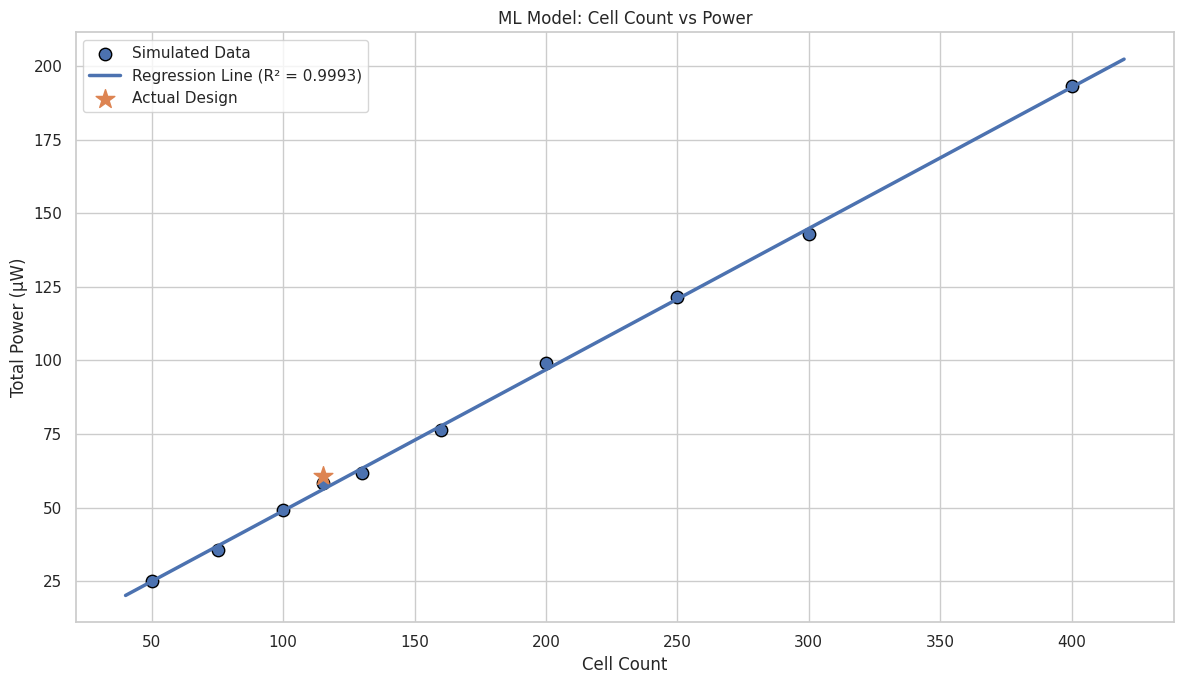

In [25]:
# Cell 12 — ML: Train and Visualize

from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# Prepare data
X = sim_df[['Cell_Count']].values
y = sim_df['Total_Power_uW'].values

# Train model
model = LinearRegression()
model.fit(X, y)

# Prediction line
X_range = np.linspace(40, 420, 300).reshape(-1, 1)
y_pred = model.predict(X_range)

# Actual design point
actual_cells = 115
actual_power = 60.8
predicted_power = model.predict([[actual_cells]])[0]

# Plot
fig, ax = plt.subplots(figsize=(12, 7))

# Scatter points
ax.scatter(X, y,
           s=80,
           edgecolors='black',
           label='Simulated Data')

# Regression line
ax.plot(X_range, y_pred,
        linewidth=2.5,
        label=f'Regression Line (R² = {model.score(X, y):.4f})')

# Highlight real design
ax.scatter(actual_cells, actual_power,
           s=200,
           marker='*',
           label='Actual Design')

# Labels
ax.set_xlabel('Cell Count')
ax.set_ylabel('Total Power (µW)')
ax.set_title('ML Model: Cell Count vs Power')

ax.legend()

# Print results
print("\nModel Results:")
print(f"Slope: {model.coef_[0]:.4f} µW per cell")
print(f"Intercept: {model.intercept_:.4f}")
print(f"R² Score: {model.score(X, y):.4f}")

print(f"\nPredicted Power (115 cells): {predicted_power:.2f} µW")
print(f"Actual Power: {actual_power} µW")
print(f"Error: {abs(predicted_power - actual_power):.2f} µW")

# Save
plt.tight_layout()
plt.savefig('/content/Data-Analytics-PBL-VLSI/plots/08_power_prediction_model.png',
            dpi=150,
            bbox_inches='tight')

plt.show()

R² Score (Area Model): 0.9885
Predicted area (115 cells): 1262.05 µm²
Actual area: 1941.86 µm²


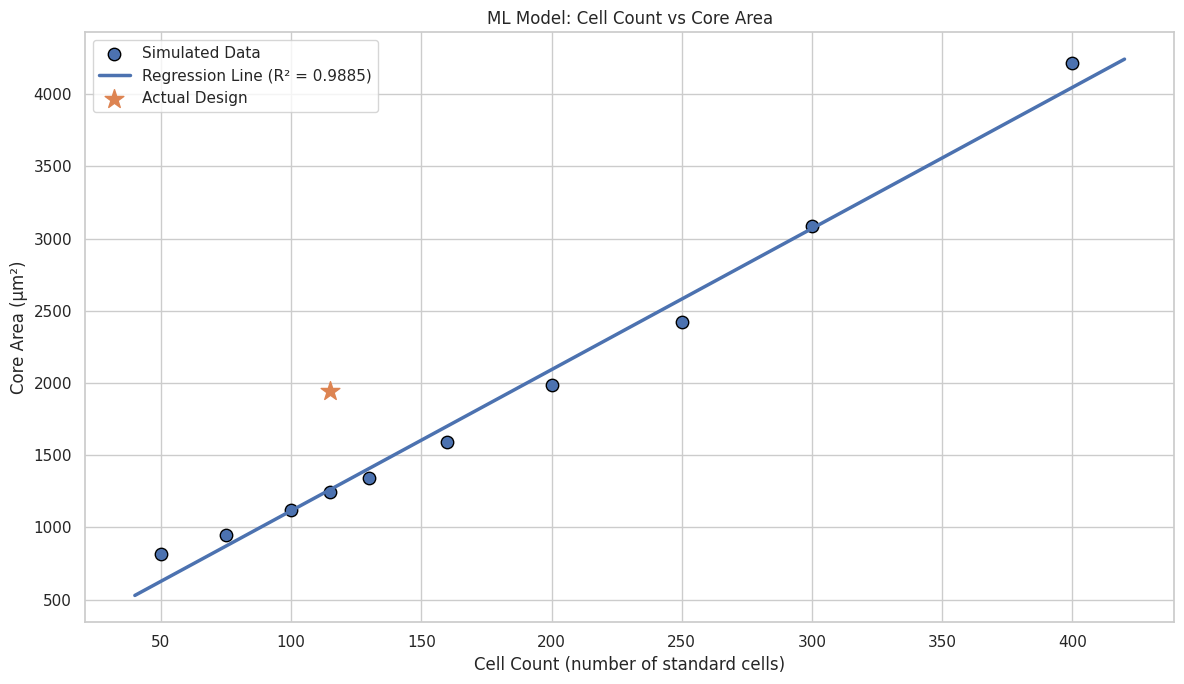

In [26]:
# Cell 13 — ML: Area Prediction Demo

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Simulated area data (µm²) vs cell count
area_data = np.array([800, 950, 1100, 1200, 1350, 1600, 1942, 2400, 3100, 4200])
np.random.seed(42)
area_noise = np.random.normal(0, 30, len(cell_counts))
core_areas = area_data + area_noise

# Train model
model_area = LinearRegression()
X = sim_df[['Cell_Count']].values
model_area.fit(X, core_areas)

# Prediction line
X_range2 = np.linspace(40, 420, 300).reshape(-1, 1)
y_pred_area = model_area.predict(X_range2)

# Actual design point
actual_cells = 115
actual_area = 1941.86
pred_area = model_area.predict([[actual_cells]])[0]

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
ax.scatter(X, core_areas, s=80, edgecolors='black', label='Simulated Data')
ax.plot(X_range2, y_pred_area, linewidth=2.5,
        label=f'Regression Line (R² = {model_area.score(X, core_areas):.4f})')
ax.scatter(actual_cells, actual_area, s=200, marker='*', label='Actual Design')

ax.set_xlabel('Cell Count (number of standard cells)')
ax.set_ylabel('Core Area (µm²)')
ax.set_title('ML Model: Cell Count vs Core Area')
ax.legend()

# Print results
print(f"R² Score (Area Model): {model_area.score(X, core_areas):.4f}")
print(f"Predicted area (115 cells): {pred_area:.2f} µm²")
print(f"Actual area: {actual_area} µm²")

# Save
plt.tight_layout()
plt.savefig('/content/Data-Analytics-PBL-VLSI/plots/09_area_prediction_model.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [27]:
print("=" * 60)
print("PROJECT SUMMARY — KEY FINDINGS")
print("=" * 60)

summary = {
    'Design': 'alu_8bit (8-bit ALU)',
    'Technology': 'Sky130 PDK (Open-Source)',
    'Flow': 'OpenLane RTL-to-GDSII',

    'Synthesis Cells': '115 standard cells',
    'Total Cells (with Physical)': '345 cells',

    'Core Area': '1941.86 µm²',
    'Total Power (Typical)': '60.8 µW',

    'Dominant Power Component': 'Switching (58.1%)',

    'Critical Path': '2.34 ns',
    'Clock Period': '10 ns',
    'Setup Slack': '+3.41 ns (34.1% margin)',

    'WNS': '0.0 (No violations)',
    'TNS': '0.0 (No violations)',

    'DRC Violations': '0',
    'LVS Errors': '0',
    'Antenna Violations': '0',

    'Routing Insight': 'Primary usage on met1 (21.88%) and met2 (27.89%) — no congestion',

    'ML Insight (Power)': 'Linear scaling observed (R² ≈ 0.999), prediction error ~4.67 µW',

    'ML Insight (Area)': 'Model underestimates due to physical design overhead (routing, decap, fill cells)'
}

for k, v in summary.items():
    print(f"{k:<40} : {v}")

print("\n" + "=" * 60)
print("FINAL STATUS")
print("=" * 60)

print("✅ Flow Status: COMPLETED SUCCESSFULLY")
print("✅ Design is DRC clean, LVS clean, and antenna-violation free")
print("✅ Timing closure achieved with positive slack on all paths")
print("✅ Design is READY for tapeout (GDSII generated)")

PROJECT SUMMARY — KEY FINDINGS
Design                                   : alu_8bit (8-bit ALU)
Technology                               : Sky130 PDK (Open-Source)
Flow                                     : OpenLane RTL-to-GDSII
Synthesis Cells                          : 115 standard cells
Total Cells (with Physical)              : 345 cells
Core Area                                : 1941.86 µm²
Total Power (Typical)                    : 60.8 µW
Dominant Power Component                 : Switching (58.1%)
Critical Path                            : 2.34 ns
Clock Period                             : 10 ns
Setup Slack                              : +3.41 ns (34.1% margin)
WNS                                      : 0.0 (No violations)
TNS                                      : 0.0 (No violations)
DRC Violations                           : 0
LVS Errors                               : 0
Antenna Violations                       : 0
Routing Insight                          : Primary usage on me

In [28]:
import shutil

# Zip the entire project folder
shutil.make_archive('/content/Data-Analytics-PBL-VLSI', 'zip', '/content/Data-Analytics-PBL-VLSI')

print("ZIP file created successfully!")

ZIP file created successfully!


In [29]:
from google.colab import files

files.download('/content/Data-Analytics-PBL-VLSI.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>